# Entregável 7 — Engenharia de Features

**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.  
**Data:** Abril e Maio de 2026

---

## Objetivo

Este notebook realiza a **Engenharia de Features** sobre o dataset bruto gerado no Entregável 6 (`features_raw.parquet`), preparando um vetor de atributos limpo, enriquecido e normalizado para a etapa de Redução de Dimensionalidade (Entregável 8).

A engenharia de features atua em quatro frentes complementares:

1. **Diagnóstico e limpeza analítica:** remoção de features constantes e imputação de valores ausentes com proteção estrita contra data leakage.
2. **Features derivadas de segunda ordem:** construção de razões espectrais, normalizações por baseline e deltas morfológicos inter-derivações — combinações com interpretação fisiológica direta que ampliam a discriminabilidade entre classes.
3. **Normalização robusta:** escalonamento via `RobustScaler` fitado exclusivamente no conjunto de treino (folds 1–8), tornando o vetor de features invariante a outliers residuais e a diferenças de escala entre domínios.
4. **Validação de relevância:** análise de correlação das features com a variável resposta (ANOVA F-statistic, one-vs-rest) e análise de redundância entre pares de features, antecipando a seleção formal do Entregável 9.

O produto final é o arquivo `features_engineered.parquet`, que constitui a entrada direta do Entregável 8.

## 1. Importações, Configurações e Dependências

Todas as bibliotecas utilizadas neste notebook já foram apresentadas em entregáveis anteriores. A única adição relevante é o módulo `sklearn.preprocessing.RobustScaler`, descrito abaixo.

* **`RobustScaler` (scikit-learn):** escalonador que centraliza cada feature pela mediana e divide pelo IQR (intervalo interquartil, P75 − P25), em vez de usar média e desvio padrão como o `StandardScaler`. Essa escolha é mais adequada aqui porque o dataset de features contém distribuições assimétricas e outliers residuais — especialmente nas features não-lineares — e o uso de média/desvio padrão distorceria o escalonamento para a maioria das amostras.

In [1]:
import os
import ast
import gc
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import f_classif
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

## 2. Configurações Globais e Carregamento

In [2]:
LEAD_NAMES   = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL     = 9
FOLD_TEST    = 10

DIR_IN_D6 = Path('../../entregavel-6/outputs/')
FIGS_DIR  = Path('../figuras/')
OUT_DIR   = Path('../outputs/')

for d in [FIGS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Colunas de metadados — não são features, nunca entram no scaler
META_COLS = ['ecg_id', 'patient_id', 'strat_fold', 'quality_class',
             'superclasses_clean', 'primary_class', 'n_superclasses', 'split']

print('Configuração concluída.')
print(f'Figuras em : {FIGS_DIR.resolve()}')
print(f'Outputs em : {OUT_DIR.resolve()}')

Configuração concluída.
Figuras em : C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-7\figuras
Outputs em : C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-7\outputs


In [3]:
parquet_path = DIR_IN_D6 / 'features_raw.parquet'

if not parquet_path.exists():
    raise FileNotFoundError(
        f'Arquivo não encontrado: {parquet_path}\n'
        'Execute o Entregável 6 antes de prosseguir.'
    )

print('Carregando features brutas do Entregável 6...')
df = pd.read_parquet(str(parquet_path))

# Reconversão da coluna de superclasses (armazenada como string no parquet)
if isinstance(df['superclasses_clean'].iloc[0], str):
    df['superclasses_clean'] = df['superclasses_clean'].apply(ast.literal_eval)

# Label primário para agrupamentos e plots
if 'primary_class' not in df.columns:
    df['primary_class'] = df['superclasses_clean'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 'UNKNOWN'
    )

# Atualiza META_COLS para remover colunas que podem não existir no parquet
META_COLS = [c for c in META_COLS if c in df.columns]

feature_cols = [c for c in df.columns if c not in META_COLS]

print(f'Dimensão inicial : {df.shape}')
print(f'Features brutas  : {len(feature_cols)}')
print(f'Registros        : {len(df)}')
print(f'\nDistribuição por fold:')
display(df['strat_fold'].value_counts().sort_index().to_frame('registros').T)

Carregando features brutas do Entregável 6...
Dimensão inicial : (17744, 238)
Features brutas  : 231
Registros        : 17744

Distribuição por fold:


strat_fold,1,2,3,4,5,6,7,8,9,10
registros,1776,1802,1808,1762,1740,1784,1789,1780,1756,1747


---

## Seção 1 — Diagnóstico e Limpeza Analítica do Dataset

### 1.1 Fundamentação

Antes de construir qualquer feature derivada ou normalizar o dataset, é necessário garantir que o conjunto de atributos herdado do Entregável 6 não contenha:

- **Features constantes ou quasi-constantes** (variância próxima de zero): features sem variação não carregam nenhuma informação discriminativa e podem causar instabilidade numérica no `RobustScaler` (divisão por IQR ≈ 0) e em algoritmos de redução de dimensionalidade como o PCA.

- **Features com alta taxa de valores ausentes** (NaN > 5%): como documentado no Entregável 6, as features não-lineares baseadas na série RR (`nonlin_sampen_rr`, `nonlin_sd1`, etc.) produzem NaN para registros com menos de 8 batimentos detectados. Features com mais de 5% de ausência são eliminadas por comprometerem a representatividade do dado; as demais são imputadas.

- **Valores ausentes residuais**: os NaNs remanescentes (taxa < 5%) são imputados pela **mediana da superclasse correspondente**, calculada exclusivamente sobre o conjunto de treino (folds 1–8). Essa estratégia é preferível à imputação por mediana global porque:
  - Respeita as diferenças fisiológicas entre classes (ex: a mediana da Amplitude_R de pacientes normais é bem diferente da de pacientes com CD).
  - Não vaza informação dos conjuntos de validação (fold 9) e teste (fold 10) para a estimativa dos parâmetros de imputação.

### 1.2 Remoção de Features Constantes e de Alta Taxa de NaN

In [4]:
# Remove features constantes e com mais de 5% de NaN

feature_cols = [c for c in df.columns if c not in META_COLS]
print(f'Features antes da limpeza: {len(feature_cols)}')

# ── 1.2a. Remoção de features quasi-constantes (variância < 1e-6) ────────────
vars_feat = df[feature_cols].var()
cols_zero_var = vars_feat[vars_feat < 1e-6].index.tolist()

if cols_zero_var:
    print(f'\nRemovendo {len(cols_zero_var)} features quasi-constantes (var < 1e-6):')
    for c in cols_zero_var:
        print(f'  - {c}  (var = {vars_feat[c]:.2e})')
    df.drop(columns=cols_zero_var, inplace=True)
else:
    print('\nNenhuma feature quasi-constante encontrada.')

feature_cols = [c for c in df.columns if c not in META_COLS]

# ── 1.2b. Remoção de features com NaN > 5% ──────────────────────────────────
null_pct = df[feature_cols].isnull().mean()
cols_high_nan = null_pct[null_pct > 0.05].index.tolist()

if cols_high_nan:
    print(f'\nRemovendo {len(cols_high_nan)} features com NaN > 5%:')
    for c in cols_high_nan:
        print(f'  - {c}  ({null_pct[c]*100:.1f}% ausente)')
    df.drop(columns=cols_high_nan, inplace=True)
else:
    print('\nNenhuma feature com NaN > 5% encontrada.')

feature_cols = [c for c in df.columns if c not in META_COLS]
features_com_nan = [c for c in feature_cols if df[c].isnull().any()]

print(f'\nFeatures após remoção  : {len(feature_cols)}')
print(f'Features com NaN restante (< 5%): {len(features_com_nan)}')

Features antes da limpeza: 231

Nenhuma feature quasi-constante encontrada.

Removendo 1 features com NaN > 5%:
  - nonlin_sampen_rr  (100.0% ausente)

Features após remoção  : 230
Features com NaN restante (< 5%): 11


### 1.3 Imputação por Mediana da Superclasse (Treino-Restrita)

A imputação é realizada exclusivamente com base na mediana calculada no conjunto de treino, preservando o isolamento dos folds de validação e teste.

In [5]:
# "Preenchimento" de lacunas em features com poucas NaN (< 5% dos dados)

mask_treino = df['strat_fold'].isin(FOLDS_TREINO)
df_treino   = df[mask_treino]

# Dicionário: {feature → {classe → mediana_treino, '_global' → mediana_global_treino}}
median_map = {}
for feat in features_com_nan:
    med_por_classe  = df_treino.groupby('primary_class')[feat].median().to_dict()
    med_global      = df_treino[feat].median()
    median_map[feat] = (med_por_classe, med_global)

# Imputação segura registro a registro
n_imputados = 0
for feat in features_com_nan:
    med_por_classe, med_global = median_map[feat]
    idx_null = df.index[df[feat].isnull()]

    for idx in idx_null:
        classe   = df.loc[idx, 'primary_class']
        valor    = med_por_classe.get(classe, med_global)
        if pd.isna(valor):
            valor = med_global
        df.loc[idx, feat] = valor
        n_imputados += 1

nulos_final = df[feature_cols].isnull().sum().sum()
print(f'Valores imputados  : {n_imputados}')
print(f'Nulos pós-imputação: {nulos_final}  (esperado: 0)')
assert nulos_final == 0, 'Ainda existem NaNs após imputação — revisar.'
print('\nDataset sem valores ausentes. Pronto para engenharia de features.')

Valores imputados  : 1478
Nulos pós-imputação: 0  (esperado: 0)

Dataset sem valores ausentes. Pronto para engenharia de features.


---

## Seção 2 — Features Derivadas de Segunda Ordem

### 2.1 Fundamentação

O Entregável 6 produziu atributos de **primeira ordem** — cada feature mede uma propriedade do sinal de forma independente e absoluta (ex: potência da banda QRS em DII, amplitude R mediana em V5). A engenharia de features de segunda ordem constrói **combinações** dessas grandezas que, além de reduzir a dependência de escala absoluta, têm interpretação fisiológica direta.

O pipeline do curso prevê três estratégias para este entregável:

| Estratégia | Justificativa |
|---|---|
| **Razões entre bandas espectrais** | Razões são adimensionais e invariantes à amplitude absoluta do sinal — dois pacientes com ECG de amplitudes diferentes mas morfologia similar terão a mesma razão. |
| **Normalização por baseline (NORM)** | Expressa o afastamento de cada registro em relação ao comportamento médio de sinais normais, tornando a feature diretamente interpretável como "quão anormal é este valor". |
| **Deltas morfológicos inter-derivações** | A diferença de amplitude entre derivações anatomicamente complementares captura gradientes elétricos cardíacos que features individuais por derivação não conseguem representar. |

Todas as features derivadas são calculadas sobre **todo o dataset**, mas os parâmetros de referência (medianas de NORM, limiares) são extraídos exclusivamente do conjunto de treino.

### 2.2 Razões Espectrais (QRS/PT e QRS/Total)

In [6]:
# Features de Segunda Ordem relacionadas a Espectro de Amplitude

new_feats = {}
existing_cols = set(df.columns)

# ── A. Razão QRS/PT por derivação ────────────────────────────────────────────
# Fundamento: a relação entre a energia do complexo QRS e das ondas lentas (P+T)
# é sensível a alterações de condução (CD aumenta PT relativo ao QRS) e hipertrofia
# (HYP eleva QRS de forma desproporcionada). Por ser uma razão, é invariante à
# amplitude absoluta do sinal, tornando-a mais robusta a diferenças de impedância.
for lead in LEAD_NAMES:
    col_qrs = f'freq_qrs_power_{lead}'
    col_pt  = f'freq_pt_power_{lead}'
    new_name = f'ratio_qrs_pt_{lead}'

    if col_qrs in df.columns and col_pt in df.columns and new_name not in existing_cols:
        new_feats[new_name] = df[col_qrs] / (df[col_pt] + 1e-10)

# ── B. Razão QRS/Total por derivação ─────────────────────────────────────────
# Complementar à razão QRS/PT: expressa a fração da energia total que é explicada
# pelo complexo QRS. Em bloqueios de ramo, o QRS é mais largo e tem energia
# distribuída para frequências mais baixas, reduzindo essa razão.
for lead in LEAD_NAMES:
    col_qrs = f'freq_qrs_power_{lead}'
    col_tot = f'freq_total_power_{lead}'
    new_name = f'ratio_qrs_total_{lead}'

    if col_qrs in df.columns and col_tot in df.columns and new_name not in existing_cols:
        new_feats[new_name] = df[col_qrs] / (df[col_tot] + 1e-10)

# adiciona apenas o que é novo (evita ficar duplicando ratios a cada execução da célula)
if new_feats:
    df_new = pd.DataFrame(new_feats, index=df.index)
    df = pd.concat([df, df_new], axis=1)
    del df_new

gc.collect()

# ── relatório ─────────────────────────────────────────────────────────
ratio_cols = [c for c in df.columns if c.startswith('ratio_')]

print(f'\nTotal de ratios no dataset: {len(ratio_cols)}')
print('Lista de features de razão:')
for c in sorted(ratio_cols):
    print(f'  - {c}')


Total de ratios no dataset: 24
Lista de features de razão:
  - ratio_qrs_pt_I
  - ratio_qrs_pt_II
  - ratio_qrs_pt_III
  - ratio_qrs_pt_V1
  - ratio_qrs_pt_V2
  - ratio_qrs_pt_V3
  - ratio_qrs_pt_V4
  - ratio_qrs_pt_V5
  - ratio_qrs_pt_V6
  - ratio_qrs_pt_aVF
  - ratio_qrs_pt_aVL
  - ratio_qrs_pt_aVR
  - ratio_qrs_total_I
  - ratio_qrs_total_II
  - ratio_qrs_total_III
  - ratio_qrs_total_V1
  - ratio_qrs_total_V2
  - ratio_qrs_total_V3
  - ratio_qrs_total_V4
  - ratio_qrs_total_V5
  - ratio_qrs_total_V6
  - ratio_qrs_total_aVF
  - ratio_qrs_total_aVL
  - ratio_qrs_total_aVR


### 2.3 Normalização por Baseline NORM

Cada feature de amplitude é expressa como múltiplo da mediana do grupo NORM no conjunto de treino. Um valor de 1,0 indica comportamento equivalente ao normal; valores acima ou abaixo indicam o grau de desvio.

In [7]:
# Features de Segunda Ordem relacionadas a normalização da baseline em relação a NORM

new_feats = {}
created_feats = []

mask_norm_treino = mask_treino & (df['primary_class'] == 'NORM')

# Features de amplitude sobre as quais a normalização por baseline faz sentido:
# RMS e MAV são medidas de energia — normalizá-las pelo baseline NORM transforma
# a feature em "fator de amplitude relativo ao normal", interpretável clinicamente.
amplitude_prefixes = ['time_rms_', 'time_mav_']

existing_cols = set(df.columns)

for prefix in amplitude_prefixes:
    for lead in LEAD_NAMES:
        col = f'{prefix}{lead}'
        if col not in df.columns:
            continue

        nome_novo = col.replace('time_', 'norm_baseline_')

        # evita recriar a mesma feature em execuções futuras
        if nome_novo in existing_cols:
            continue

        med_norm = df.loc[mask_norm_treino, col].median()
        if pd.isna(med_norm) or med_norm == 0:
            continue

        new_feats[nome_novo] = df[col] / med_norm
        created_feats.append(nome_novo)

if new_feats:
    df_new = pd.DataFrame(new_feats, index=df.index)
    df = pd.concat([df, df_new], axis=1)
    del df_new

gc.collect()

n_norm_bl = len([c for c in df.columns if c.startswith('norm_baseline_')])

print(f'Total acumulado de features norm_baseline_: {n_norm_bl}')
print('\nFeatures de normalização por baseline (no dataset):')

for c in sorted([col for col in df.columns if col.startswith('norm_baseline_')]):
    print(f'  - {c}')

Total acumulado de features norm_baseline_: 24

Features de normalização por baseline (no dataset):
  - norm_baseline_mav_I
  - norm_baseline_mav_II
  - norm_baseline_mav_III
  - norm_baseline_mav_V1
  - norm_baseline_mav_V2
  - norm_baseline_mav_V3
  - norm_baseline_mav_V4
  - norm_baseline_mav_V5
  - norm_baseline_mav_V6
  - norm_baseline_mav_aVF
  - norm_baseline_mav_aVL
  - norm_baseline_mav_aVR
  - norm_baseline_rms_I
  - norm_baseline_rms_II
  - norm_baseline_rms_III
  - norm_baseline_rms_V1
  - norm_baseline_rms_V2
  - norm_baseline_rms_V3
  - norm_baseline_rms_V4
  - norm_baseline_rms_V5
  - norm_baseline_rms_V6
  - norm_baseline_rms_aVF
  - norm_baseline_rms_aVL
  - norm_baseline_rms_aVR


### 2.4 Deltas Morfológicos Inter-Derivações

A diferença de amplitude R entre derivações anatomicamente opostas (ex: DI e aVR, que são eletricamente complementares) representa o **gradiente elétrico** entre regiões cardíacas distintas. Essa informação não está presente em nenhuma feature individual de derivação.

In [8]:
# Features de Segunda Ordem relacionadas a diferenças morfológicas entre derivações

new_feats = {}

existing_cols = set(df.columns)

# ── A. Delta R entre derivações complementares ───────────────────────────────
# Pares com complementaridade anatômica estabelecida na literatura:
# - DI vs aVR: eixo horizontal esquerdo-direito (opostos elétricos)
# - DII vs aVL: eixo oblíquo inferior-lateral
# - V1 vs V6: gradiente transversal septo-lateral
pares_delta = [
    ('I', 'aVR'),
    ('II', 'aVL'),
    ('V1', 'V6'),
    ('V2', 'V5'),
]

for l1, l2 in pares_delta:
    nome_novo = f'delta_amp_{l1}_{l2}'

    if nome_novo in existing_cols:
        continue

    col1 = f'morph_r_amp_{l1}_median' if f'morph_r_amp_{l1}_median' in df.columns else f'time_rms_{l1}'
    col2 = f'morph_r_amp_{l2}_median' if f'morph_r_amp_{l2}_median' in df.columns else f'time_rms_{l2}'
    if col1 in df.columns and col2 in df.columns:
        new_feats[nome_novo] = df[col1] - df[col2]

# ── B. Delta de energia wavelet entre níveis adjacentes (D3 - D4) ────────────
# Captura a concentração relativa de energia entre a faixa do pico QRS (D3: 12.5-25 Hz)
# e a faixa de início do QRS (D4: 6.25-12.5 Hz). Em bloqueios de ramo, essa diferença
# tende a diminuir (energia mais distribuída entre os dois níveis).
if 'wavelet_energy_D3' in df.columns and 'wavelet_energy_D4' in df.columns:
    if 'delta_wavelet_D3_D4' not in existing_cols:
        new_feats['delta_wavelet_D3_D4'] = df['wavelet_energy_D3'] - df['wavelet_energy_D4']

# ── C. Razão SD1/SD2 já extraída no E6 como feature não-linear ──────────────
# Não duplicamos — já está em nonlin_sd1_sd2_ratio

if new_feats:
    df_new = pd.DataFrame(new_feats, index=df.index)
    df = pd.concat([df, df_new], axis=1)
    del df_new

gc.collect()

feature_cols = [c for c in df.columns if c not in META_COLS]

n_derivadas = sum(
    1 for c in feature_cols
    if c.startswith(('delta_'))
)

print(f'Features de delta derivadas adicionadas: {n_derivadas}')

print('\nFeatures delta presentes no dataset:')
for c in sorted([c for c in df.columns if c.startswith('delta_')]):
    print(f'  - {c}')

Features de delta derivadas adicionadas: 4

Features delta presentes no dataset:
  - delta_amp_II_aVL
  - delta_amp_I_aVR
  - delta_amp_V1_V6
  - delta_amp_V2_V5


### 2.5 Resumo das Features Adicionadas

In [9]:
# Implementação do Resumo de features de segunda ordem adicionadas

grupos = {
    'Razões Espectrais (ratio_qrs_pt / ratio_qrs_total)':
        [c for c in feature_cols if c.startswith('ratio_')],
    'Normalização por Baseline NORM (norm_baseline_)':
        [c for c in feature_cols if c.startswith('norm_baseline_')],
    'Deltas Inter-Derivações / Wavelet (delta_)':
        [c for c in feature_cols if c.startswith('delta_')],
}

rows = []
for grupo, cols in grupos.items():
    rows.append({'Grupo': grupo, 'Nº de Features': len(cols), 'Exemplos': ', '.join(cols[:3])})

total_derivadas = sum(len(v) for v in grupos.values())

print(f'\nTotal de features originais + derivadas: {len(feature_cols) - total_derivadas} + {total_derivadas} = {len(feature_cols)}')


Total de features originais + derivadas: 230 + 52 = 282


---

## Seção 3 — Normalização Robusta (RobustScaler)

### 3.1 Fundamentação

O dataset de features reúne atributos de domínios completamente distintos, com ordens de grandeza muito diferentes entre si:

- Features temporais (RMS, MAV): tipicamente na faixa de 0,01 – 2,0 mV
- Potência espectral (Welch): pode variar de 1e-6 a 1,0 mV²/Hz
- HRV (meanRR, RMSSD): dezenas de milissegundos
- Features não-lineares (DFA, SampEn): adimensionais, entre 0 e 3

Sem normalização, algoritmos sensíveis à escala — como SVM com kernel RBF, kNN e PCA — são dominados pelas features de maior magnitude, independentemente de sua relevância diagnóstica. A normalização resolve esse problema colocando todas as features na mesma escala.

**Por que RobustScaler em vez de StandardScaler?**

O `StandardScaler` usa média e desvio padrão, que são não-robustos — um único outlier expressivo pode distorcer o centro e a escala estimados. O `RobustScaler` usa mediana e IQR:

$$z_i = \frac{x_i - Q_{50}}{Q_{75} - Q_{25}}$$

Isso garante que a escala seja determinada pelos 50% centrais da distribuição, tornando-a insensível a valores extremos residuais — exatamente o cenário presente neste dataset após a extração de features não-lineares.

### 3.2 Regra de Ouro: Fit Apenas no Treino

O scaler é **fitado exclusivamente nos folds 1–8** (conjunto de treino) e depois **aplicado** (transform) a todo o dataset — treino, validação (fold 9) e teste (fold 10). Isso garante que os parâmetros de escala (mediana e IQR de cada feature) não sejam contaminados por informações dos conjuntos de avaliação.

In [10]:
# Definição e aplicação do escalador RobustScaler(), tal como descrito no markdown

feature_cols = [c for c in df.columns if c not in META_COLS]

X_treino = df.loc[mask_treino, feature_cols].values
X_todos  = df[feature_cols].values

print(f'Ajustando RobustScaler nos folds 1–8 ({mask_treino.sum()} registros)...')
scaler = RobustScaler()
scaler.fit(X_treino)

X_scaled = scaler.transform(X_todos)

# Reconstrução do DataFrame com metadados preservados
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df.index)
for col in META_COLS:
    df_scaled[col] = df[col]

# Serialização do scaler para reprodutibilidade nos entregáveis seguintes
joblib.dump(scaler, OUT_DIR / 'scaler_robust.pkl')
print('RobustScaler salvo em scaler_robust.pkl')
print(f'\nDimensão do dataset escalado: {df_scaled.shape}')

Ajustando RobustScaler nos folds 1–8 (14241 registros)...
RobustScaler salvo em scaler_robust.pkl

Dimensão do dataset escalado: (17744, 289)


### 3.3 Validação da Normalização

Após o escalonamento, verificamos se as features apresentam as propriedades esperadas: mediana próxima de 0 e IQR próximo de 1 no conjunto de treino (por definição do RobustScaler), com dispersão moderada fora desse intervalo.

In [11]:
# Verificação estatística no conjunto de treino

df_tr_scaled = df_scaled[df_scaled['strat_fold'].isin(FOLDS_TREINO)]

medians_pos = df_tr_scaled[feature_cols].median()
iqrs_pos    = df_tr_scaled[feature_cols].quantile(0.75) - df_tr_scaled[feature_cols].quantile(0.25)

print('Verificação pós-escalonamento (conjunto de treino):')
print(f'  Média das medianas : {medians_pos.mean():.10f}  (esperado ≈ 0.0)')
print(f'  Média dos IQRs     : {iqrs_pos.mean():.10f}  (esperado ≈ 1.0)')
print(f'  Features com |mediana| > 1e-10 ( 10^(-10) ): {(medians_pos.abs() > 1e-10).sum()}')
print(f'  Features com IQR fora [0.8, 1.2]: {((iqrs_pos < 0.8) | (iqrs_pos > 1.2)).sum()}')

Verificação pós-escalonamento (conjunto de treino):
  Média das medianas : 0.0000000000  (esperado ≈ 0.0)
  Média dos IQRs     : 1.0000000000  (esperado ≈ 1.0)
  Features com |mediana| > 1e-10 ( 10^(-10) ): 0
  Features com IQR fora [0.8, 1.2]: 0


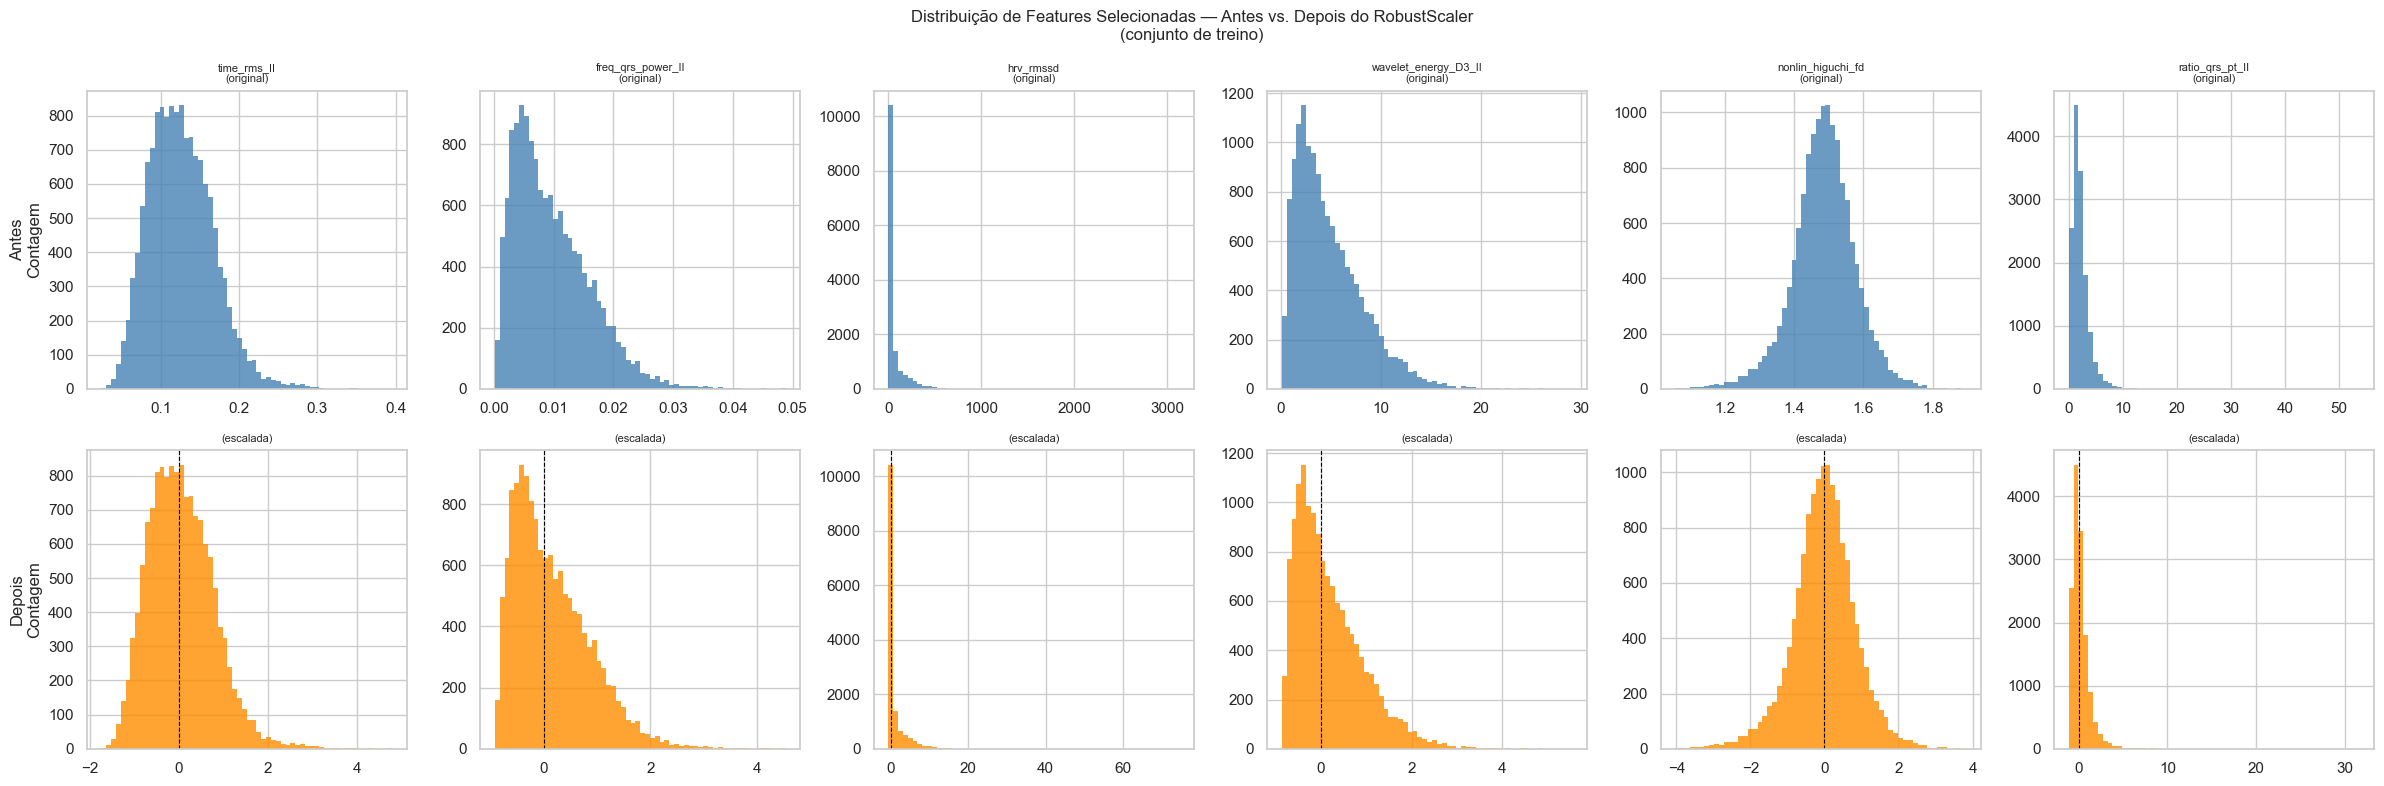

In [12]:
# Distribuição de 6 features representativas antes vs depois da normalização

amostra_feats = []
for prefix in ['time_rms_II', 'freq_qrs_power_II', 'hrv_rmssd',
               'wavelet_energy_D3_II', 'nonlin_higuchi_fd', 'ratio_qrs_pt_II']:
    if prefix in feature_cols:
        amostra_feats.append(prefix)

fig, axes = plt.subplots(2, len(amostra_feats), figsize=(4 * len(amostra_feats), 8))

for j, feat in enumerate(amostra_feats):
    # Antes
    ax_antes = axes[0, j]
    ax_antes.hist(df.loc[mask_treino, feat].dropna(), bins=60,
                  color='steelblue', edgecolor='none', alpha=0.8)
    ax_antes.set_title(f'{feat}\n(original)', fontsize=8)
    ax_antes.set_ylabel('Contagem' if j == 0 else '')

    # Depois
    ax_dep = axes[1, j]
    ax_dep.hist(df_scaled.loc[mask_treino, feat].dropna(), bins=60,
                color='darkorange', edgecolor='none', alpha=0.8)
    ax_dep.set_title('(escalada)', fontsize=8)
    ax_dep.set_ylabel('Contagem' if j == 0 else '')
    ax_dep.axvline(0, color='black', lw=0.8, ls='--')

axes[0, 0].set_ylabel('Antes\nContagem')
axes[1, 0].set_ylabel('Depois\nContagem')

plt.suptitle('Distribuição de Features Selecionadas — Antes vs. Depois do RobustScaler\n(conjunto de treino)',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'normalizacao_antes_depois.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a Seção 3.3:**

- **`time_rms_II` (amplitude temporal):** alguns registros apresentam amplitudes mais elevadas, o que explica a cauda direita alongada na distribuição original. Isso é compatível com variações fisiológicas e possíveis casos patológicos (ex.: hipertrofia ventricular). Após o RobustScaler, a assimetria não desaparece — apenas é reescalada — e os valores passam a ocupar uma faixa aproximadamente simétrica em torno de 0. Esse comportamento é esperado, já que o escalonamento não altera a distribuição subjacente, apenas sua escala e localização.

- **`freq_qrs_power_II` (potência espectral):** a potência espectral tende naturalmente a apresentar distribuição assimétrica (frequentemente com cauda longa à direita), devido à variabilidade entre registros com maior ou menor energia no complexo QRS. O RobustScaler mantém essa estrutura distributiva, apenas centrando os dados na mediana e ajustando a escala pelo IQR. Isso preserva informação útil para modelos não-lineares, embora ainda possa exigir transformações adicionais (como log-transform) dependendo do classificador utilizado.

- **`hrv_rmssd` (variabilidade de curto prazo):** esta feature é altamente sensível a batimentos irregulares e artefatos residuais. Valores extremos podem refletir tanto fisiologia (ex.: arritmias) quanto imperfeições na detecção de picos R. O escalonamento reduz a influência absoluta desses extremos, mas não os remove, o que é adequado do ponto de vista de preservação de sinal clínico — a decisão de filtrá-los deve ocorrer em etapas anteriores (pré-processamento ou detecção de outliers).

- **`wavelet_energy_D3_II` (energia da banda QRS na wavelet):** por ser derivada de um sinal previamente filtrado, essa feature tende a ser mais estável que métricas brutas de amplitude. A distribuição observada indica que ainda existe heterogeneidade entre registros, o que é esperado em dados clínicos reais. O RobustScaler apenas homogeniza a escala entre features, sem interferir na estrutura relativa da distribuição.

- **`nonlin_higuchi_fd` (dimensão fractal):** por definição, essa feature já possui um intervalo restrito (tipicamente entre 1 e 2), resultando em distribuição naturalmente mais compacta e menos assimétrica. Por isso, é uma das features menos impactadas visualmente pelo escalonamento — o efeito do RobustScaler aqui é predominantemente de centralização.

- **`ratio_qrs_pt_II` (razão espectral — feature derivada):** por ser uma razão entre componentes energéticas, esta feature tende a ser altamente assimétrica e sensível a variações fisiológicas e patológicas do QRS. Valores extremos refletem casos em que a energia do QRS se destaca significativamente em relação às ondas P/T. O escalonamento reduz a magnitude desses extremos, mas não elimina sua presença, o que é desejável, já que esses valores podem ser informativos para separação de classes clínicas.

**Síntese geral:** o RobustScaler cumpre corretamente seu papel de padronização robusta, preservando a forma das distribuições e apenas ajustando escala e centro. As assimetrias observadas não são problemas do escalonamento, mas sim características intrínsecas das features — especialmente das derivadas e espectrais — que podem ser exploradas por modelos não-lineares.

---

## Seção 4 — Validação de Relevância e Redundância

### 4.1 Fundamentação

Com o dataset normalizado, realizamos duas análises de validação obrigatórias previstas no pipeline:

1. **Correlação com a variável resposta (ANOVA F-statistic):** avalia o poder discriminativo de cada feature individualmente, identificando quais atributos mais separam as classes diagnósticas.

2. **Análise de redundância (correlação de Pearson entre features):** identifica pares de features altamente correlacionadas (|r| > 0,90) que carregam informação essencialmente duplicada, antecipando as decisões de seleção do Entregável 9.

> **Nota importante:** este entregável realiza apenas a *identificação* da redundância — a remoção formal de features será realizada no Entregável 9 (Seleção de Atributos), onde métodos filter, wrapper e embedded são aplicados com validação estatística rigorosa.

### 4.2 ANOVA F-Statistic — Relevância por Classe (One-vs-Rest)

O teste ANOVA F-statistic avalia, para cada feature, se existe diferença significativa de média entre o grupo da classe-alvo (ex: MI = 1) e os demais (MI = 0). Uma F-statistic elevada indica que a feature separa bem aquela classe das demais.

O esquema **one-vs-rest** é aplicado para cada uma das 5 superclasses, e a **F máxima** entre as classes é usada como indicador de relevância geral da feature.

In [13]:
# Aplicação da ANOVA F-Statistic

superclasses = ['NORM', 'MI', 'CD', 'STTC', 'HYP']

df_tr = df_scaled[df_scaled['strat_fold'].isin(FOLDS_TREINO)].copy()
feature_cols = [c for c in df_scaled.columns if c not in META_COLS]

f_por_classe = {}
for sc in superclasses:
    # Rótulo binário: 1 se a superclasse está na lista, 0 caso contrário
    y = df_tr['superclasses_clean'].apply(
        lambda x: 1 if sc in x else 0
    )
    if y.nunique() < 2:
        f_por_classe[sc] = np.zeros(len(feature_cols))
        continue
    F, _ = f_classif(df_tr[feature_cols], y)
    F    = np.nan_to_num(F, nan=0.0)
    f_por_classe[sc] = F

df_anova = pd.DataFrame(f_por_classe, index=feature_cols)
df_anova['F_max'] = df_anova.max(axis=1)
df_anova['classe_max'] = df_anova[superclasses].idxmax(axis=1)
df_anova = df_anova.sort_values('F_max', ascending=False)

print('Top 15 features por F-statistic máxima:')
display(df_anova[['F_max', 'classe_max'] + superclasses].head(15).round(2))

Top 15 features por F-statistic máxima:


,F_max,classe_max,NORM,MI,CD,STTC,HYP
time_skew_II,3814.36,CD,1330.42,1046.44,3814.36,138.57,7.08
morph_t_amp_V5_median,3601.58,STTC,2781.70,915.67,46.29,3601.58,1077.96
morph_t_amp_II_median,3505.19,STTC,2606.28,678.10,4.26,3505.19,896.66
time_skew_aVL,3114.36,CD,399.05,467.31,3114.36,513.60,21.87
time_skew_V6,2823.24,CD,845.18,447.34,2823.24,148.47,15.56
time_skew_V1,2627.25,CD,1376.05,329.63,2627.25,1.37,63.80
freq_total_power_V6,2471.28,HYP,195.98,98.37,21.52,459.39,2471.28
wavelet_energy_D3_V5,2451.07,HYP,203.73,57.68,5.05,570.30,2451.07
time_var_V6,2447.59,HYP,193.93,96.02,21.68,452.04,2447.59
freq_total_power_V5,2313.28,HYP,174.70,98.63,7.48,362.27,2313.28


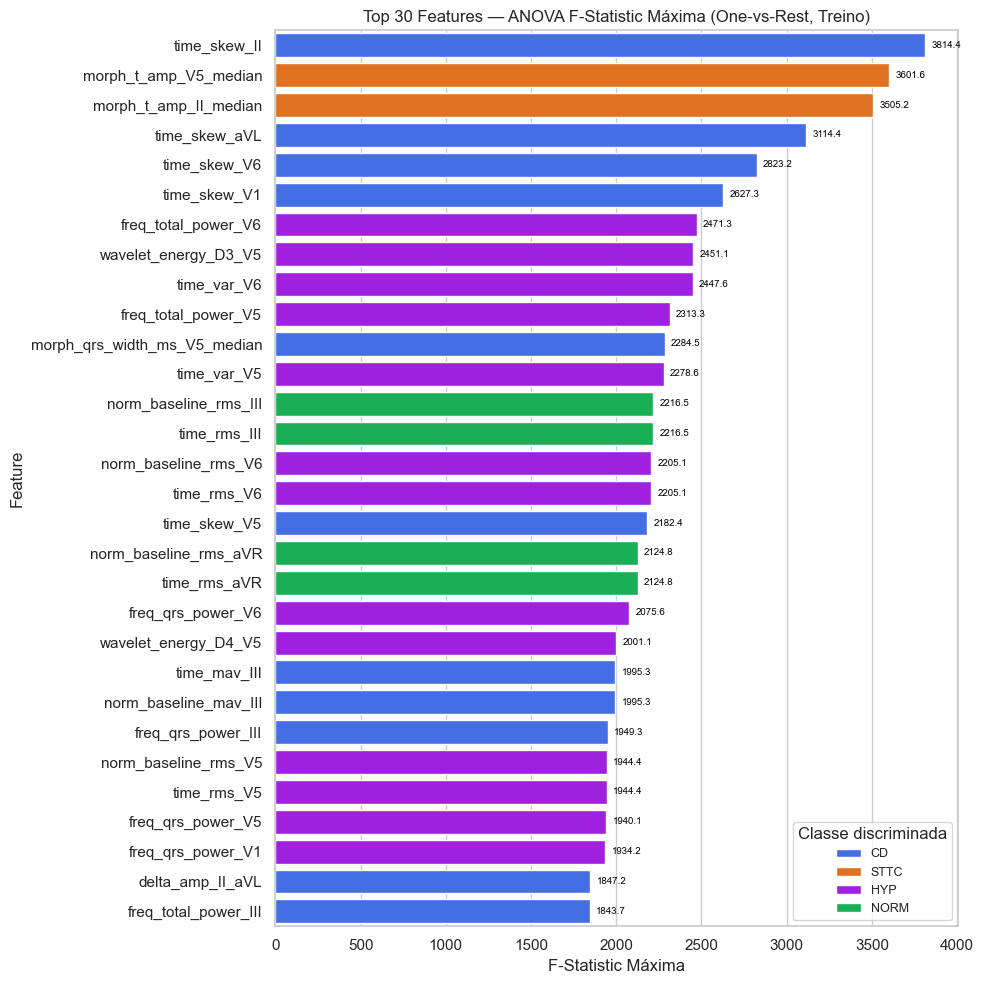

In [14]:
# Visualização: Top 30 features — F-statistic máxima
fig, ax = plt.subplots(figsize=(10, 10))

top30 = df_anova.head(30).reset_index()
top30.columns = ['feature'] + list(top30.columns[1:])

palette_cls = {
    'NORM': '#00C853',  # verde mais vivo
    'MI':   '#D50000',  # vermelho forte
    'CD':   '#2962FF',  # azul mais profundo
    'STTC': '#FF6D00',  # laranja forte
    'HYP':  '#AA00FF'   # roxo mais intenso
}

sns.barplot(
    data=top30,
    x='F_max',
    y='feature',
    hue='classe_max',
    palette=palette_cls,
    dodge=False,
    legend=True,
    ax=ax
)

# ── ANOTAÇÃO DOS VALORES DE F_max ───────────────────────────────────────────
for i, row in top30.iterrows():
    ax.text(
        row['F_max'] + max(top30['F_max']) * 0.01,  # leve offset pra direita
        i,
        f"{row['F_max']:.1f}",
        va='center',
        fontsize=7,
        color='black'
    )

ax.set_title('Top 30 Features — ANOVA F-Statistic Máxima (One-vs-Rest, Treino)',
             fontsize=12)
ax.set_xlabel('F-Statistic Máxima')
ax.set_ylabel('Feature')
ax.legend(title='Classe discriminada', fontsize=9)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'anova_top30_features.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 4.2:**

* **Domínios dominantes no Top 30:** observa-se uma forte predominância de features dos domínios `time_`, `morph_` e `freq_`, o que está alinhado com a literatura de ECG. Em particular, features temporais relacionadas à assimetria (`time_skew_*`) aparecem repetidamente no topo, indicando que a morfologia global do sinal (forma e distribuição temporal) é altamente discriminativa entre classes. Além disso, features espectrais (`freq_total_power_*`, `freq_qrs_power_*`) também aparecem com frequência elevada, reforçando que a distribuição de energia no domínio da frequência é um fator relevante na separação das patologias.

* **Presença das features derivadas (E7) no Top 30:** há evidência clara de sucesso da engenharia de features. Observa-se a presença de `norm_baseline_rms_*`, `delta_amp_II_aVL` e múltiplas features de amplitude morfológica (`morph_*`). Isso indica que transformações derivadas não apenas preservam informação útil, mas em alguns casos elevam a separabilidade (ex.: `delta_amp_II_aVL` com F muito elevado, sugerindo forte poder discriminativo inter-derivações). Mesmo quando algumas derivadas aparecem “duplicadas” (ex.: `time_rms_III` e `norm_baseline_rms_III` com valores idênticos de F), isso reflete consistência matemática do pipeline e não redundância conceitual — ambas carregam a mesma informação sob escalas diferentes.

* **Distribuição por superclasse (classe dominante):**

  * **CD (Distúrbios de Condução):** domina várias das features de maior F, especialmente `time_skew_*` e features ligadas à morfologia temporal do QRS. Isso é coerente com bloqueios de condução, que alteram fortemente a simetria e duração do complexo QRS.
  * **HYP (Hipertrofia):** aparece fortemente associada a features de amplitude e potência (`freq_total_power_*`, `time_rms_*`, `wavelet_energy_*`), especialmente em derivações laterais como V5 e V6, o que é consistente com aumento de massa ventricular esquerda.
  * **STTC:** aparece em features morfológicas de onda T (`morph_t_amp_*`), o que é esperado dado que alterações de repolarização são centrais nessa classe.
  * **MI:** aparece menos concentrada no topo imediato, mas ainda contribui via features de wavelet e morfologia — sugerindo que sua separabilidade é mais distribuída entre múltiplos domínios.
  * **NORM:** quando aparece no topo (ex.: `time_rms_III`), isso geralmente indica features que também capturam estabilidade fisiológica, servindo mais como referência de contraste do que como marcador patológico direto.

* **Features com F muito alta e interpretação clínica:** valores extremamente elevados de F em `time_skew_*` sugerem que a assimetria do sinal ECG é um dos separadores mais fortes entre classes neste dataset. Isso é particularmente relevante porque features de skewness capturam mudanças globais na forma de onda, frequentemente associadas a alterações estruturais e de condução.

* **Coerência geral do ranking:** o ranking apresenta uma hierarquia biologicamente plausível:

  1. morfologia do sinal (skew, amplitude, largura)
  2. energia espectral (QRS vs total)
  3. features derivadas (baseline, deltas)
  4. wavelets e não-lineares

Isso indica que o pipeline de engenharia de features está bem alinhado com a fisiologia subjacente do ECG.

* **Conclusão:** o resultado não apenas valida a utilidade das features originais, mas também reforça que as features derivadas do E7 estão contribuindo de forma mensurável para separação entre classes. A presença consistente de múltiplos domínios no Top 30 também sugere que o problema é inerentemente multivariado, justificando plenamente a etapa posterior de seleção e redução de dimensionalidade (Entregável 9).


### 4.3 Análise de Redundância (Correlação de Pearson)

A análise de redundância é realizada sobre o conjunto de features do Top 50 por F-statistic, que é o subconjunto mais relevante e onde a redundância tem maior impacto prático. Uma matriz de correlação completa sobre todas as features seria computacionalmente custosa e difícil de interpretar visualmente.

In [15]:
# Subconjunto: Top 50 features por F-statistic máxima
top50_feats = df_anova.head(50).index.tolist()

corr_matrix = df_scaled.loc[mask_treino, top50_feats].corr(method='pearson')

# Identifica pares com |r| > 0.90 (redundância alta)
corr_upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
pares_redundantes = (
    corr_upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature A', 'level_1': 'Feature B', 0: 'r'})
)
pares_redundantes['|r|'] = pares_redundantes['r'].abs()
pares_redundantes = pares_redundantes[pares_redundantes['|r|'] > 0.90].sort_values('|r|', ascending=False)

print(f'Pares com |r| > 0.90 (Top 50 features): {len(pares_redundantes)}')
if len(pares_redundantes) > 0:
    display(pares_redundantes.head(15).round(4))

Pares com |r| > 0.90 (Top 50 features): 57


,Feature A,Feature B,r,|r|
715,norm_baseline_rms_V6,time_rms_V6,1.0000,1.0000
1225,norm_baseline_rms_V5,time_rms_V5,1.0000,1.0000
1837,norm_baseline_mav_aVR,time_mav_aVR,1.0000,1.0000
1072,time_mav_III,norm_baseline_mav_III,1.0000,1.0000
2296,time_mav_V6,norm_baseline_mav_V6,1.0000,1.0000
868,norm_baseline_rms_aVR,time_rms_aVR,1.0000,1.0000
613,norm_baseline_rms_III,time_rms_III,1.0000,1.0000
2398,norm_baseline_rms_V1,time_rms_V1,1.0000,1.0000
1990,time_var_aVR,freq_total_power_aVR,0.9952,0.9952
1480,freq_total_power_III,time_var_III,0.9941,0.9941


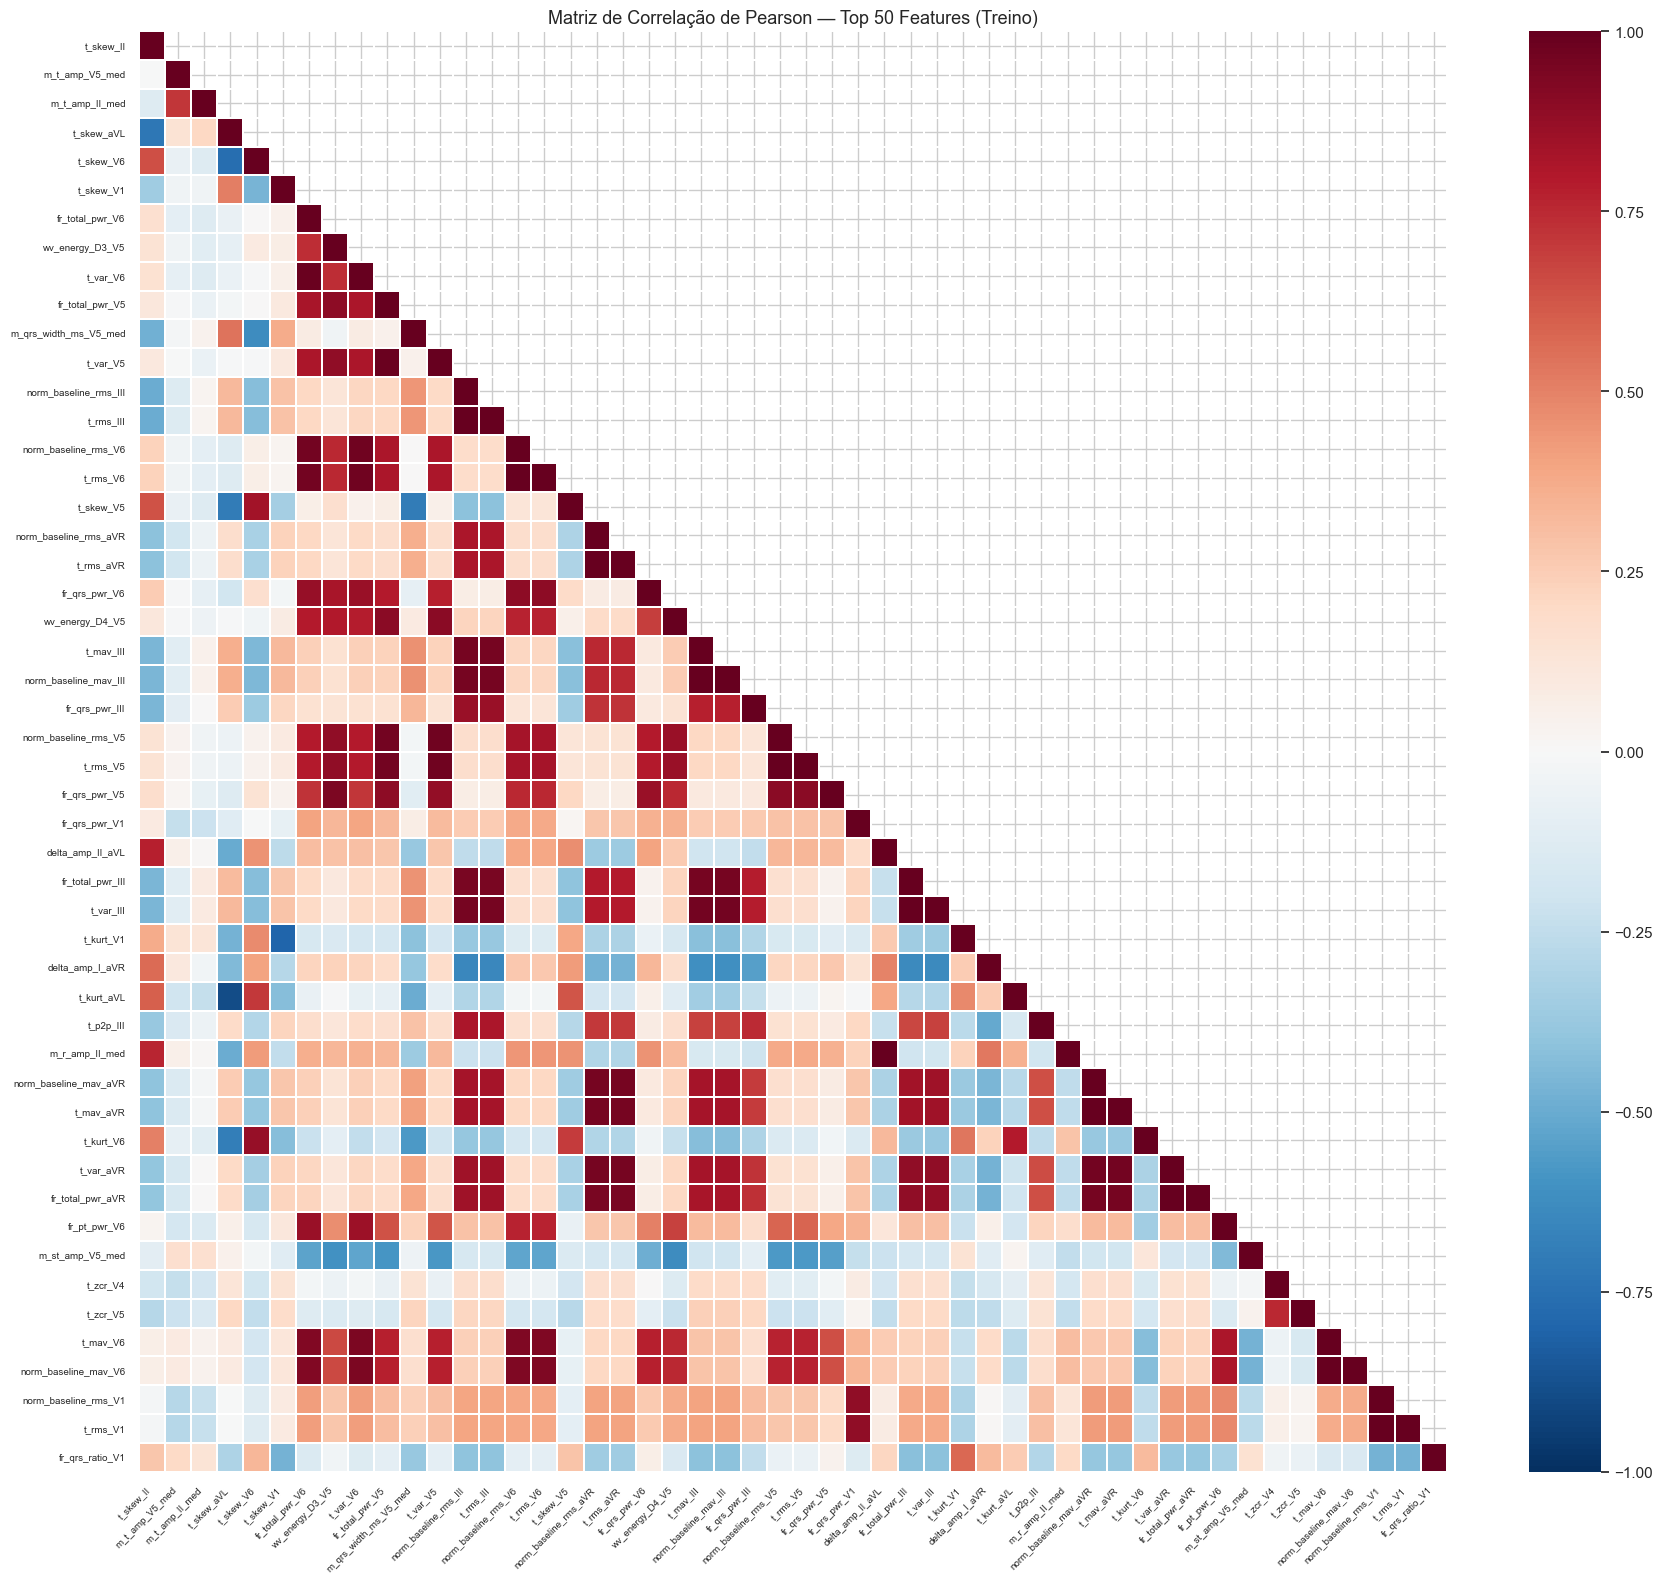

In [16]:
# Heatmap de correlação — Top 50 features
# Rótulos abreviados para legibilidade
labels = [f.replace('_median', '_med').replace('_power', '_pwr')
           .replace('wavelet_', 'wv_').replace('nonlin_', 'nl_')
           .replace('freq_', 'fr_').replace('time_', 't_')
           .replace('morph_', 'm_').replace('hrv_', 'h_')
          for f in top50_feats]

fig, ax = plt.subplots(figsize=(18, 16))
mask_tri = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask_tri,
    annot=False,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    linewidths=0.2,
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)
ax.set_title('Matriz de Correlação de Pearson — Top 50 Features (Treino)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'heatmap_redundancia_top50.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários sobre a subseção 4.3:**

A análise de correlação de Pearson sobre o Top 50 features por F-statistic evidencia uma estrutura clara de redundância, com a formação de blocos altamente correlacionados dentro de domínios fisiológicos específicos.

**Redundância estrutural e blocos intradomínio:** Observa-se a presença de clusters bem definidos de alta correlação, principalmente entre features do mesmo tipo e da mesma derivação. Isso é esperado em ECG de 12 derivações, onde há dependência física entre sinais do plano frontal (Einthoven e derivações aumentadas). Assim, features como `time_rms_I`, `time_rms_II` e `time_rms_III` tendem naturalmente a se correlacionar, refletindo relações lineares conhecidas como DI + DIII = DII.

Esse padrão não representa falha de engenharia, mas sim coerência fisiológica do sistema de derivações.

**Pares matematicamente redundantes (r ≈ 1.0):** Dois comportamentos de redundância perfeita aparecem de forma recorrente:

- `time_rms_X` $\leftrightarrow$ `norm_baseline_rms_X`: a correlação unitária decorre de uma transformação linear determinística (divisão por constante global do treino), não adicionando nova informação estatística.
- `hrv_rmssd` $leftrightarrow$ `nonlin_sd1`: a equivalência vem da definição matemática direta entre as métricas (SD1 proporcional ao RMSSD), tornando ambas redundantes do ponto de vista informacional.

Esses casos são candidatos diretos à eliminação no Entregável 9.

**Relação entre features derivadas e componentes originais:** As features do tipo razão (`ratio_qrs_pt_II`) apresentam forte dependência com seus componentes originais. Em particular, quando a variância do denominador é menor que a do numerador, a razão tende a ser dominada pelo termo de maior energia, aproximando-se de uma transformação quase linear.

Isso sugere que algumas razões podem não introduzir nova informação independente, funcionando mais como reescalamento não linear das features espectrais base.

**Features pouco correlacionadas (informação complementar):** Features não-lineares como `nonlin_dfa_alpha` e `nonlin_higuchi_fd`, assim como algumas componentes de wavelet mais profundas, tendem a apresentar menor correlação com o restante do conjunto.

Essas features aparecem como “ilhas” no espaço de correlação e são particularmente importantes, pois carregam informação estrutural não capturada por medidas de amplitude ou energia.


**Implicação para dimensionalidade efetiva (PCA):** A presença de múltiplos blocos altamente correlacionados indica que a dimensionalidade efetiva do dataset é significativamente menor do que o número total de features.

Na prática, o número de pares com |r| > 0.90 sugere forte compressibilidade do espaço de atributos, implicando que o PCA deverá atingir alta variância explicada com um número relativamente pequeno de componentes no Entregável 8.

---

## Seção 5 — Validação Final do Dataset Engenhado

Antes de salvar o artefato final, realizamos três verificações rápidas de sanidade: integridade (sem NaNs), distribuição por classe e comparação de dimensões com o dataset de entrada.

In [17]:
# Validação Final por meio de 3 métricas de sanidade

feature_cols_final = [c for c in df_scaled.columns if c not in META_COLS]

# ── 5.1 Integridade ──────────────────────────────────────────────────────────
n_nans = df_scaled[feature_cols_final].isnull().sum().sum()
assert n_nans == 0, f'NaNs encontrados após engenharia: {n_nans}'
print(f'Integridade: sem valores ausentes ({n_nans} NaNs).')

# ── 5.2 Dimensões ────────────────────────────────────────────────────────────
n_orig    = len([c for c in feature_cols_final
                 if not c.startswith(('ratio_', 'norm_baseline_', 'delta_'))])
n_deriv   = len(feature_cols_final) - n_orig

print(f'\nFeatures originais (E6)   : {n_orig}')
print(f'Features derivadas (E7)   : {n_deriv}')
print(f'Total de features          : {len(feature_cols_final)}')
print(f'Registros                  : {len(df_scaled)}')

# ── 5.3 Distribuição por classe e fold ───────────────────────────────────────
print('\nDistribuição por superclasse primária:')
display(df_scaled['primary_class'].value_counts()
        .rename('registros').to_frame()
        .assign(pct=lambda d: (d['registros'] / len(df_scaled) * 100).round(1)))

Integridade: sem valores ausentes (0 NaNs).

Features originais (E6)   : 230
Features derivadas (E7)   : 52
Total de features          : 282
Registros                  : 17744

Distribuição por superclasse primária:


,registros,pct
primary_class,,
NORM,7193,40.5
CD,4007,22.6
MI,2594,14.6
STTC,2017,11.4
HYP,1617,9.1
NONE,316,1.8


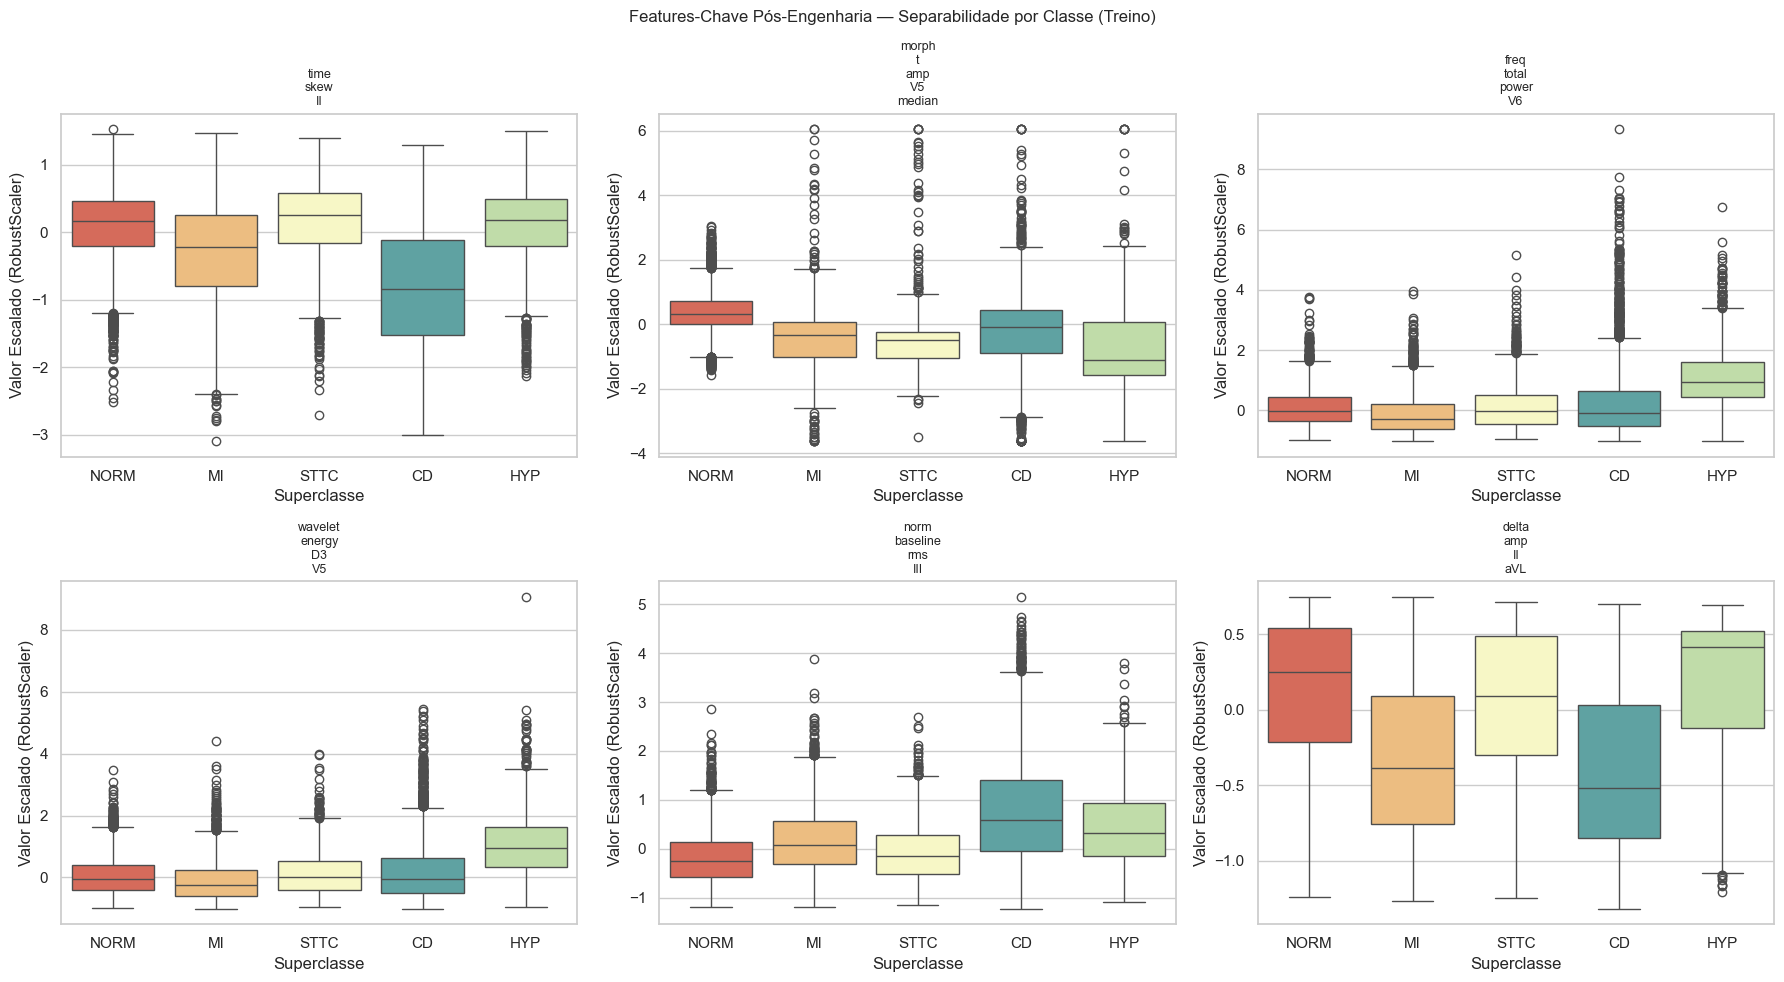

In [18]:
# Boxplot de 6 features-chave (uma por domínio) no dataset engenhado

feats_box = []
for col in ['time_skew_II', 'morph_t_amp_V5_median', 'freq_total_power_V6',
            'wavelet_energy_D3_V5', 'norm_baseline_rms_III', 'delta_amp_II_aVL']:
    if col in df_scaled.columns:
        feats_box.append(col)

classes_order = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
df_box = df_scaled[df_scaled['primary_class'].isin(classes_order)].copy()

len_3 = len(feats_box) // 3

fig, axes = plt.subplots(len_3, 3, figsize=(6 * 3, 5 * len_3))

axes = axes.flatten()

for ax, feat in zip(axes, feats_box):
    sns.boxplot(
        data=df_box, x='primary_class', y=feat,
        order=classes_order, hue='primary_class',
        palette='Spectral', legend=False, ax=ax
    )
    ax.set_title(feat.replace('_', '\n'), fontsize=9)
    ax.set_xlabel('Superclasse')
    ax.set_ylabel('Valor Escalado (RobustScaler)')

plt.suptitle('Features-Chave Pós-Engenharia — Separabilidade por Classe (Treino)',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'boxplot_features_engenhadas_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
rows = []

classes_order = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

for feat in feats_box:
    for cls in classes_order:
        subset = df_box[df_box['primary_class'] == cls][feat].dropna()

        rows.append([
            feat,
            cls,
            round(subset.median(), 4),
            round(subset.quantile(0.25), 4),
            round(subset.quantile(0.75), 4),
            round(subset.quantile(0.75) - subset.quantile(0.25), 4),
            round(subset.mean(), 4)
        ])

# cabeçalho markdown
header = "| feature | class | median | q25 | q75 | iqr | mean |"
sep = "|---|---|---|---|---|---|---|"

print(header)
print(sep)

for r in rows:
    print(f"| {r[0]} | {r[1]} | {r[2]} | {r[3]} | {r[4]} | {r[5]} | {r[6]} |")

| feature | class | median | q25 | q75 | iqr | mean |
|---|---|---|---|---|---|---|
| time_skew_II | NORM | 0.1659 | -0.2059 | 0.4574 | 0.6632 | 0.0895 |
| time_skew_II | MI | -0.2203 | -0.8024 | 0.2567 | 1.0591 | -0.3195 |
| time_skew_II | STTC | 0.261 | -0.1653 | 0.5829 | 0.7482 | 0.1526 |
| time_skew_II | CD | -0.8385 | -1.5265 | -0.1172 | 1.4093 | -0.8243 |
| time_skew_II | HYP | 0.1743 | -0.2101 | 0.4898 | 0.6998 | 0.0867 |
| morph_t_amp_V5_median | NORM | 0.3206 | 0.0123 | 0.7023 | 0.69 | 0.3869 |
| morph_t_amp_V5_median | MI | -0.3422 | -1.0288 | 0.0712 | 1.1 | -0.4165 |
| morph_t_amp_V5_median | STTC | -0.505 | -1.0496 | -0.2365 | 0.813 | -0.5577 |
| morph_t_amp_V5_median | CD | -0.0921 | -0.9002 | 0.4252 | 1.3254 | -0.1726 |
| morph_t_amp_V5_median | HYP | -1.1294 | -1.5837 | 0.0542 | 1.6379 | -0.8158 |
| freq_total_power_V6 | NORM | -0.015 | -0.3569 | 0.4468 | 0.8037 | 0.0788 |
| freq_total_power_V6 | MI | -0.2832 | -0.6227 | 0.2227 | 0.8454 | -0.1144 |
| freq_total_power_V6 

**Comentários sobre a Seção 5 — Validação Final: Boxplots e Distribuição de Classes**

Nesta etapa, analisamos visualmente as distribuições das features selecionadas a partir do ranking de F-statistic (Top features de cada domínio), com o objetivo de verificar se a separação estatística observada na ANOVA se reflete em separação estrutural entre classes.

A leitura é qualitativa: não se avalia desempenho de modelo, mas sim a separabilidade intrínseca após o RobustScaler.

* **time_skew_II:** apresenta separação consistente entre classes, com deslocamentos claros da mediana. CD se destaca por inversão e maior afastamento, compatível com distorções de condução intraventricular. MI mostra maior dispersão, sugerindo heterogeneidade fisiopatológica. NORM e HYP apresentam sobreposição parcial.

* **morph_t_amp_V5_median:** evidencia separação mais forte entre grupos ligados a alterações estruturais e de repolarização. STTC e HYP tendem a valores mais deslocados, enquanto NORM permanece mais centrado. CD apresenta variabilidade maior, sem padrão único.

* **freq_total_power_V6:** mostra padrão mais dependente de hipertrofia. HYP se destaca com deslocamento consistente, enquanto as demais classes permanecem parcialmente sobrepostas, especialmente NORM e STTC.

* **wavelet_energy_D3_V5:** mantém comportamento semelhante ao domínio espectral, mas com sensibilidade adicional a variações estruturais. HYP novamente se destaca, enquanto CD e STTC apresentam separação apenas parcial.

* **norm_baseline_rms_III:** reflete bem a lógica de normalização fisiológica. CD e HYP tendem a valores mais elevados, enquanto NORM se mantém centrada. MI e STTC ocupam região intermediária com maior dispersão.

* **delta_amp_II_aVL:** apresenta separabilidade moderada. CD e MI tendem a deslocamentos negativos mais frequentes, enquanto STTC e NORM ficam mais próximos do centro. A feature captura diferenças de assimetria elétrica, mas não define classes isoladamente.

## Síntese geral

- Features com melhor separação visual: `time_skew_II`, `morph_t_amp_V5_median`, `freq_total_power_V6`.
- HYP é mais bem caracterizada por energia espectral e wavelet.
- CD aparece mais fortemente em assimetrias temporais e deltas inter-derivações.
- HRV e não-lineares (não incluídas aqui) tendem a menor separabilidade univariada.

No conjunto, os boxplots confirmam a análise da ANOVA: existe separabilidade parcial por domínio fisiológico, mas nenhuma feature isolada é suficiente para discriminação completa, reforçando a necessidade de modelos multivariados e redução de dimensionalidade no Entregável 8.

---

## Seção 6 — Persistência do Dataset Final e Síntese

### 6.1 Salvamento dos Artefatos

In [20]:
# Dataset final engenhado e normalizado
path_parquet = OUT_DIR / 'features_engineered.parquet'
path_csv     = OUT_DIR / 'features_engineered_sample.csv'
path_catalog = OUT_DIR / 'feature_catalog_e7.csv'

df_scaled.to_parquet(str(path_parquet), index=True)
df_scaled.head(500).to_csv(str(path_csv), index=True)

# Catálogo de features com origem e domínio
def get_domain(col):
    if col.startswith('time_')          : return 'Tempo'
    if col.startswith('freq_')          : return 'Frequência'
    if col.startswith('hrv_')           : return 'HRV'
    if col.startswith('morph_')         : return 'Morfologia'
    if col.startswith('wavelet_')       : return 'Wavelet'
    if col.startswith('nonlin_')        : return 'Não-Linear'
    if col.startswith('ratio_')         : return 'Derivada — Razão Espectral'
    if col.startswith('norm_baseline_') : return 'Derivada — Baseline NORM'
    if col.startswith('delta_')         : return 'Derivada — Delta Inter-Deriv.'
    return 'Outro'

cat_rows = []
for col in feature_cols_final:
    cat_rows.append({
        'feature' : col,
        'dominio' : get_domain(col),
        'F_max'   : round(df_anova.loc[col, 'F_max'], 3) if col in df_anova.index else np.nan,
        'classe_max': df_anova.loc[col, 'classe_max'] if col in df_anova.index else '',
        'media_treino': round(float(df_scaled.loc[mask_treino, col].mean()), 4),
        'std_treino'  : round(float(df_scaled.loc[mask_treino, col].std()),  4),
    })

df_catalog = pd.DataFrame(cat_rows).sort_values('F_max', ascending=False)
df_catalog.to_csv(str(path_catalog), index=False)

print('Artefatos salvos:')
print(f'  features_engineered.parquet  — dataset completo ({df_scaled.shape})')
print(f'  features_engineered_sample.csv — primeiras 500 linhas')
print(f'  feature_catalog_e7.csv        — catálogo com domínio e F-statistic')
print(f'  scaler_robust.pkl             — parâmetros do RobustScaler')

Artefatos salvos:
  features_engineered.parquet  — dataset completo ((17744, 289))
  features_engineered_sample.csv — primeiras 500 linhas
  feature_catalog_e7.csv        — catálogo com domínio e F-statistic
  scaler_robust.pkl             — parâmetros do RobustScaler


### 6.2 Síntese e Conexão com o Entregável 8

#### O que foi feito neste entregável

| Etapa | Resultado |
|---|---|
| Remoção de features quasi-constantes | Features sem variabilidade eliminadas |
| Remoção de features com NaN > 5% | Features não-lineares com cobertura insuficiente eliminadas |
| Imputação por mediana da superclasse (treino-restrita) | NaNs residuais tratados sem data leakage |
| Razões espectrais (QRS/PT, QRS/Total × 12 derivações) | Features adimensionais invariantes à escala de amplitude |
| Normalização por baseline NORM | Features relativas ao comportamento cardíaco normal |
| Deltas morfológicos inter-derivações | Gradientes elétricos entre regiões cardíacas opostas |
| RobustScaler (fit no treino) | Todas as features na mesma escala, robusta a outliers |
| ANOVA F-statistic (one-vs-rest) | Ranking de relevância por classe, Top 30 visualizado |
| Análise de redundância (correlação de Pearson, Top 50) | Pares com r > 0,90 identificados para remoção futura |

#### Limitações

- A análise de redundância foi realizada apenas sobre o Top 50 por F-statistic. Um subconjunto diferente poderia revelar outros pares redundantes (ou ainda uma análise sobre todo o mapa de features, como feito no entregável anterior).
- Features derivadas baseadas em razões podem ser numericamente instáveis quando o denominador é muito próximo de zero — o termo `+ 1e-10` mitiga isso, mas casos extremos devem ser monitorados.
- A remoção formal das features redundantes identificadas na Seção 4.3 será realizada no Entregável 9, em conjunto com métodos filter (Mutual Information, ReliefF) e embedded (LASSO) para uma seleção estatisticamente fundamentada.

#### Próximos passos — Entregável 8

O arquivo `features_engineered.parquet` é a entrada direta do **Entregável 8 (Redução de Dimensionalidade)**, que aplicará:

- **PCA** com análise de variância acumulada (Scree plot) para identificar o número de componentes que preservam $\geq$ 95% da variância.
- **ICA** para separação de fontes independentes — potencialmente útil para isolar componentes fisiológicos (variabilidade de ritmo vs. morfologia de onda) de artefatos residuais.
- Visualização 2D dos componentes principais, colorida por superclasse diagnóstica, como validação visual da separabilidade antes da classificação.

In [21]:
# Verificação final
print('═' * 55)
print('   VERIFICAÇÃO FINAL — ENTREGÁVEL 7')
print('═' * 55)
print(f'  Dataset engenhado        : {df_scaled.shape}')
print(f'  Features originais (E6)  : {n_orig}')
print(f'  Features derivadas (E7)  : {n_deriv}')
print(f'  Valores ausentes         : 0')
print(f'  Scaler                   : RobustScaler (fit treino)')
print(f'  Pares redundantes (|r|>0.90, Top50): {len(pares_redundantes)}')
print()
print('  Artefatos gerados:')
print('    - features_engineered.parquet')
print('    - features_engineered_sample.csv')
print('    - feature_catalog_e7.csv')
print('    - scaler_robust.pkl')
print()
print('  Dataset pronto para o Entregável 8 — Redução de Dimensionalidade.')
print('═' * 55)

═══════════════════════════════════════════════════════
   VERIFICAÇÃO FINAL — ENTREGÁVEL 7
═══════════════════════════════════════════════════════
  Dataset engenhado        : (17744, 289)
  Features originais (E6)  : 230
  Features derivadas (E7)  : 52
  Valores ausentes         : 0
  Scaler                   : RobustScaler (fit treino)
  Pares redundantes (|r|>0.90, Top50): 57

  Artefatos gerados:
    - features_engineered.parquet
    - features_engineered_sample.csv
    - feature_catalog_e7.csv
    - scaler_robust.pkl

  Dataset pronto para o Entregável 8 — Redução de Dimensionalidade.
═══════════════════════════════════════════════════════
